<a href="https://colab.research.google.com/github/denismitali17/linear_regression/blob/main/Summative_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Summative Assignment: Power Consumption Analysis and Prediction for Tétouan, Morocco


This notebook presents a comprehensive analysis of power consumption data from Tétouan, Morocco.
The goal is to build regression models to predict power consumption across three different zones.

# 1. Import Required Libraries

In [ ]:
%pip install matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

1.1 Set style for plots

In [5]:
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
sns.set_palette('viridis')

# 2. Data Loading & Preprocessing

In [6]:
print("Loading dataset...")
df = pd.read_csv('powerconsumption.csv')

Loading dataset...


2.1 Data inspection

In [45]:
print("\n=== Dataset Overview ===")
print(f"Shape: {df.shape}")
print("\nFirst 10 rows:")
display(df.head(10))


=== Dataset Overview ===
Shape: (52416, 13)

First 10 rows:


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,Hour,DayOfWeek,Month,DayOfYear
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,0,6,1,1
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,0,6,1,1
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,0,6,1,1
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,0,6,1,1
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,0,6,1,1
5,2017-01-01 00:50:00,5.853,76.9,0.081,0.059,0.108,26624.81013,17416.41337,18130.12048,0,6,1,1
6,2017-01-01 01:00:00,5.641,77.7,0.080,0.048,0.096,25998.98734,16993.31307,17945.06024,1,6,1,1
7,2017-01-01 01:10:00,5.496,78.2,0.085,0.055,0.093,25446.07595,16661.39818,17459.27711,1,6,1,1
8,2017-01-01 01:20:00,5.678,78.1,0.081,0.066,0.141,24777.72152,16227.35562,17025.54217,1,6,1,1
9,2017-01-01 01:30:00,5.491,77.3,0.082,0.062,0.111,24279.49367,15939.20973,16794.21687,1,6,1,1


2.2 Check data types and missing values

In [46]:
print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Data Types ===
Datetime                  datetime64[ns]
Temperature                      float64
Humidity                         float64
WindSpeed                        float64
GeneralDiffuseFlows              float64
DiffuseFlows                     float64
PowerConsumption_Zone1           float64
PowerConsumption_Zone2           float64
PowerConsumption_Zone3           float64
Hour                               int32
DayOfWeek                          int32
Month                              int32
DayOfYear                          int32
dtype: object

=== Missing Values ===
Datetime                  0
Temperature               0
Humidity                  0
WindSpeed                 0
GeneralDiffuseFlows       0
DiffuseFlows              0
PowerConsumption_Zone1    0
PowerConsumption_Zone2    0
PowerConsumption_Zone3    0
Hour                      0
DayOfWeek                 0
Month                     0
DayOfYear                 0
dtype: int64


# 3. Feature Engineering

In [47]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['Hour'] = df['Datetime'].dt.hour
df['DayOfWeek'] = df['Datetime'].dt.dayofweek
df['Month'] = df['Datetime'].dt.month
df['DayOfYear'] = df['Datetime'].dt.dayofyear

4. Exploratory Data Analysis (EDA)

4.1 Time Series Plot

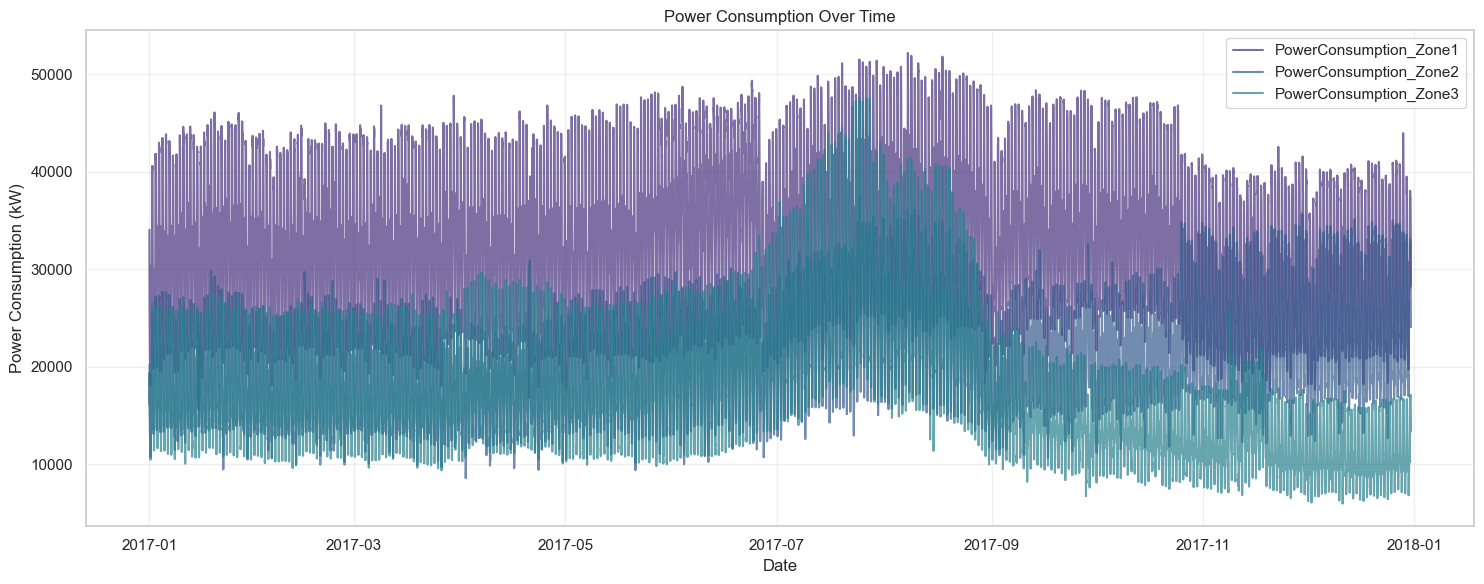

In [48]:
plt.figure(figsize=(15, 6))
for zone in ['PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']:
    plt.plot(df['Datetime'], df[zone], label=zone, alpha=0.7)
plt.title('Power Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Power Consumption (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

4.2 Correlation Heatmap

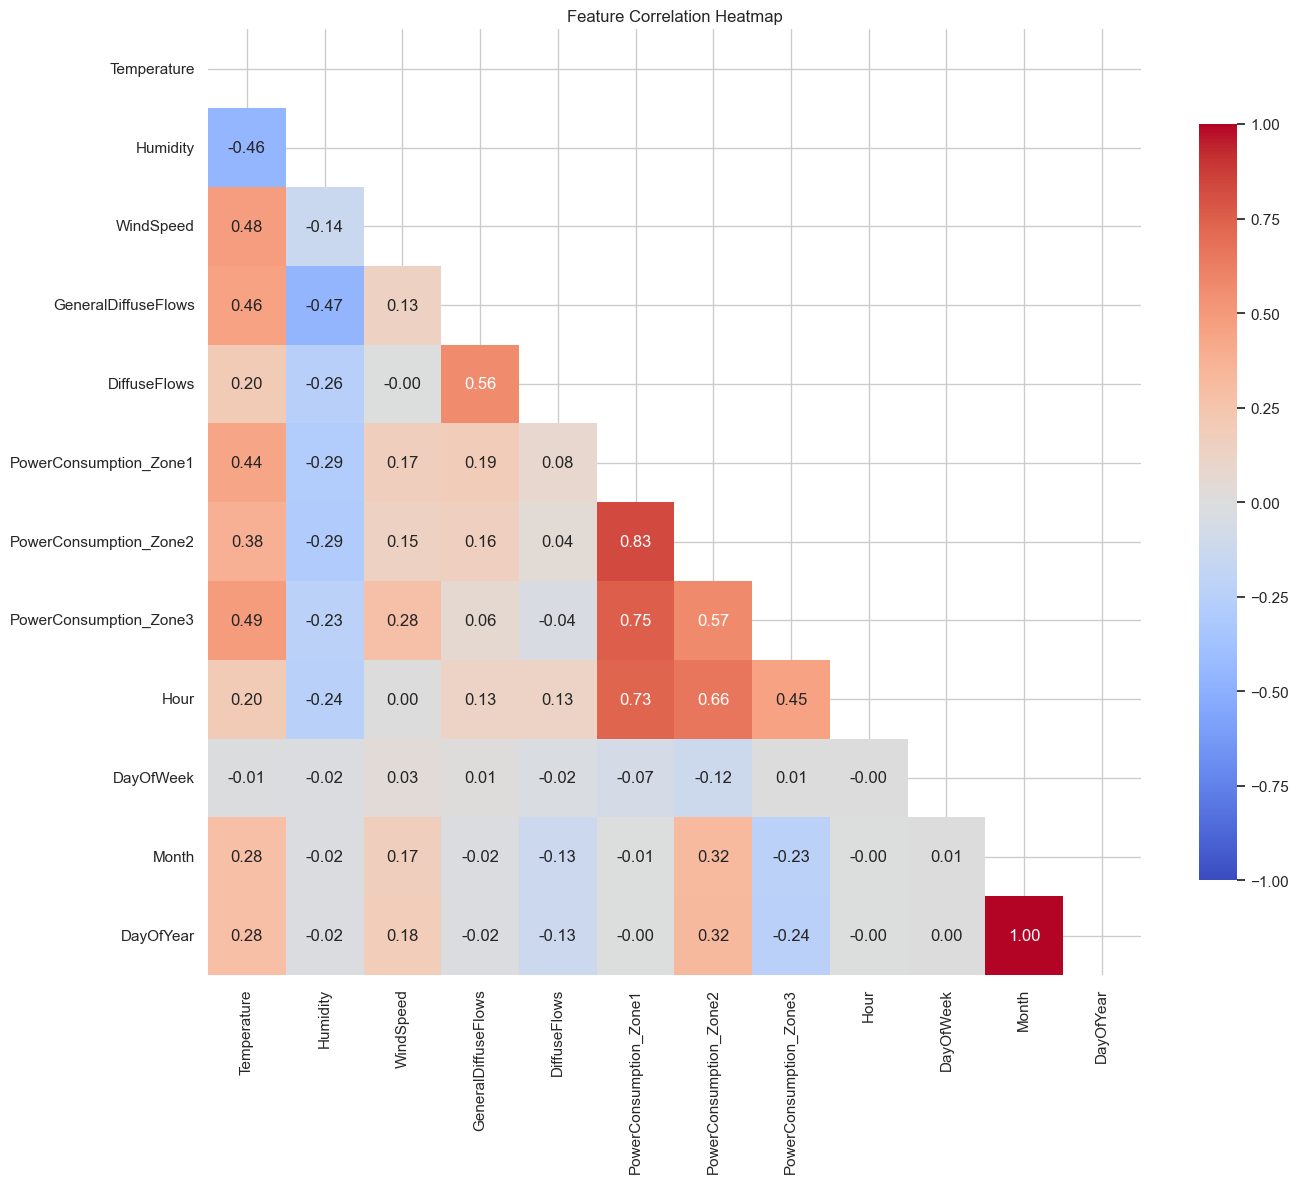

In [49]:
plt.figure(figsize=(14, 12))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, vmin=-1, vmax=1, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

4.3 Target Variable Distributions

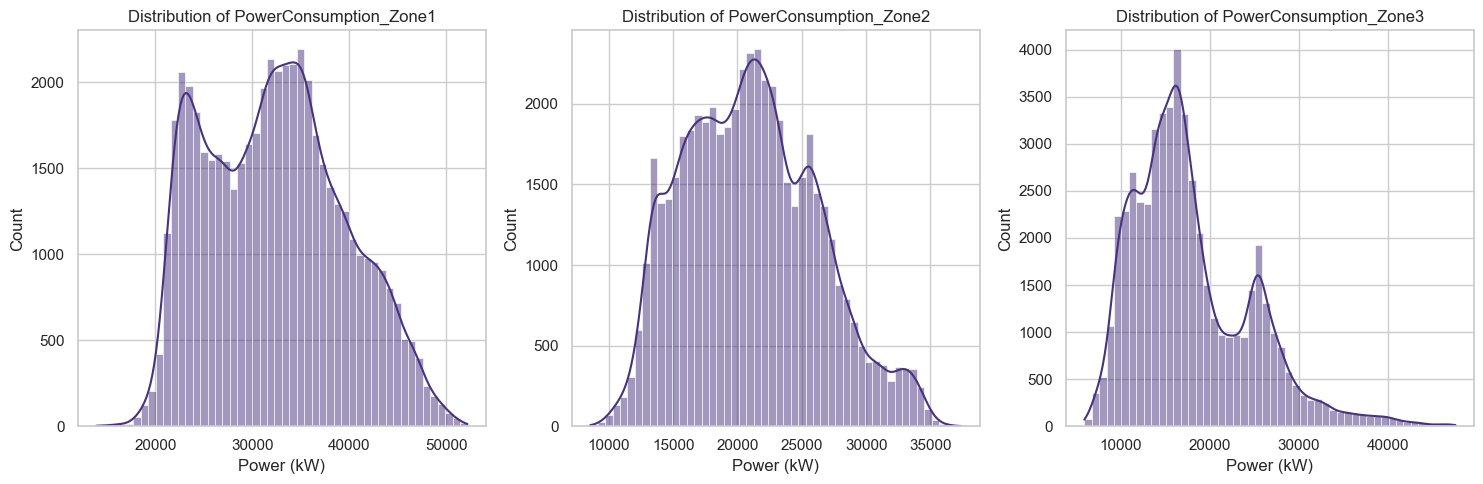

In [50]:
plt.figure(figsize=(15, 5))
for i, zone in enumerate(['PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3'], 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[zone], kde=True, bins=50)
    plt.title(f'Distribution of {zone}')
    plt.xlabel('Power (kW)')
plt.tight_layout()
plt.show()

4.4 Daily Patterns

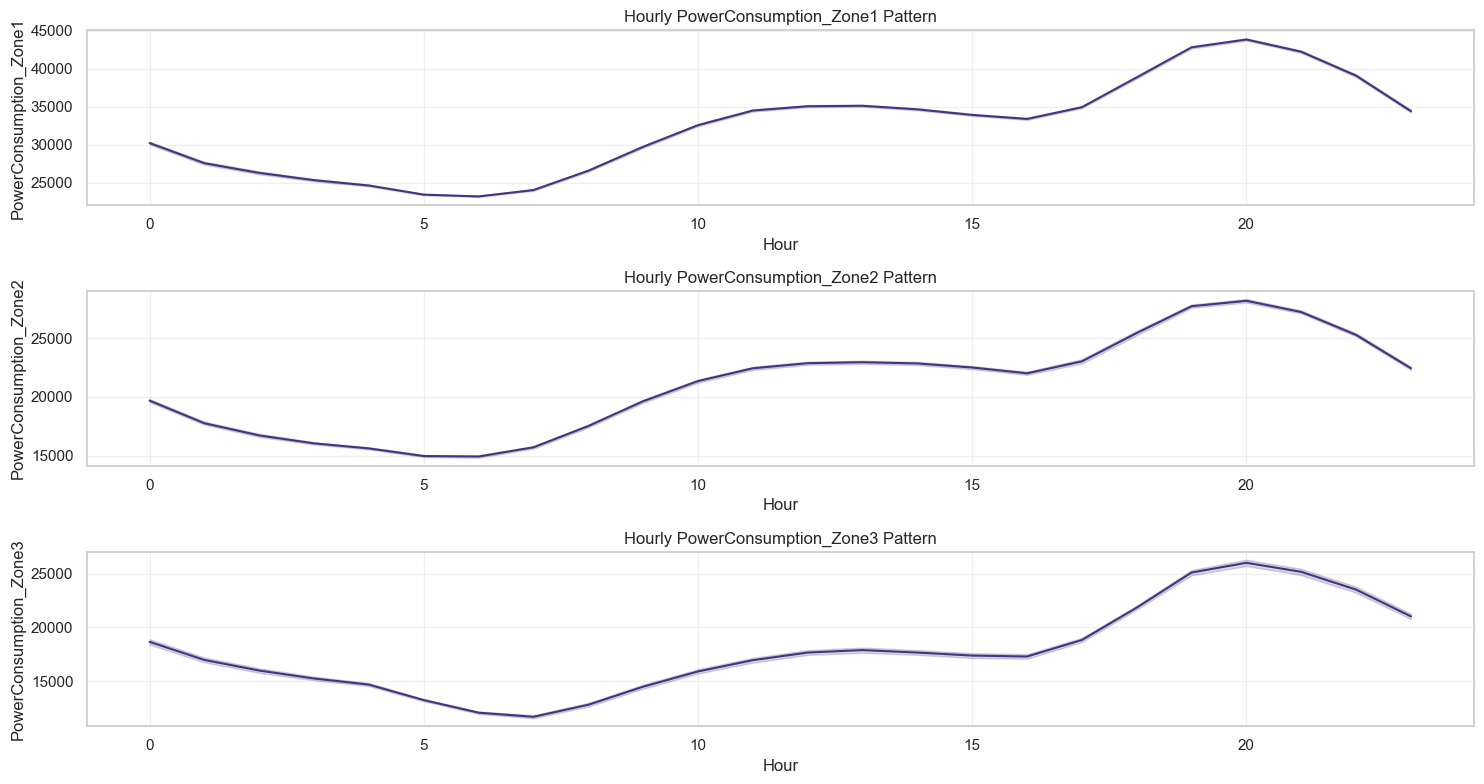

In [51]:
plt.figure(figsize=(15, 8))
for i, zone in enumerate(['PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3'], 1):
    plt.subplot(3, 1, i)
    sns.lineplot(data=df, x='Hour', y=zone, ci=95)
    plt.title(f'Hourly {zone} Pattern')
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Prepare Data for Modeling

 5.1 Dictionary to store model performance

In [52]:
model_performance = {}

5.2 Selected features and target

In [53]:
features = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows',
            'Hour', 'DayOfWeek', 'Month']
target = 'PowerConsumption_Zone1'

X = df[features]
y = df[target]

5.3 Split the data

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

5.4 Standardize features

In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Model Training and Evaluation

6.1 Linear Regression with Gradient Descent (SGD)

In [56]:
print("Training Linear Regression with Gradient Descent...")
sgd = SGDRegressor(
    max_iter=1000,
    tol=1e-3,
    learning_rate='adaptive',
    eta0=0.01,
    early_stopping=False,
    random_state=42
)

Training Linear Regression with Gradient Descent...


6.2 Store loss values

In [57]:
train_errors, val_errors = [], []

6.3 Partial fit to track loss

In [58]:
for epoch in range(100):
    sgd.partial_fit(X_train_scaled, y_train)
    y_train_predict = sgd.predict(X_train_scaled)
    y_val_predict = sgd.predict(X_test_scaled)
    train_errors.append(mean_squared_error(y_train, y_train_predict))
    val_errors.append(mean_squared_error(y_test, y_val_predict))

6.4 Plot Learning Curves

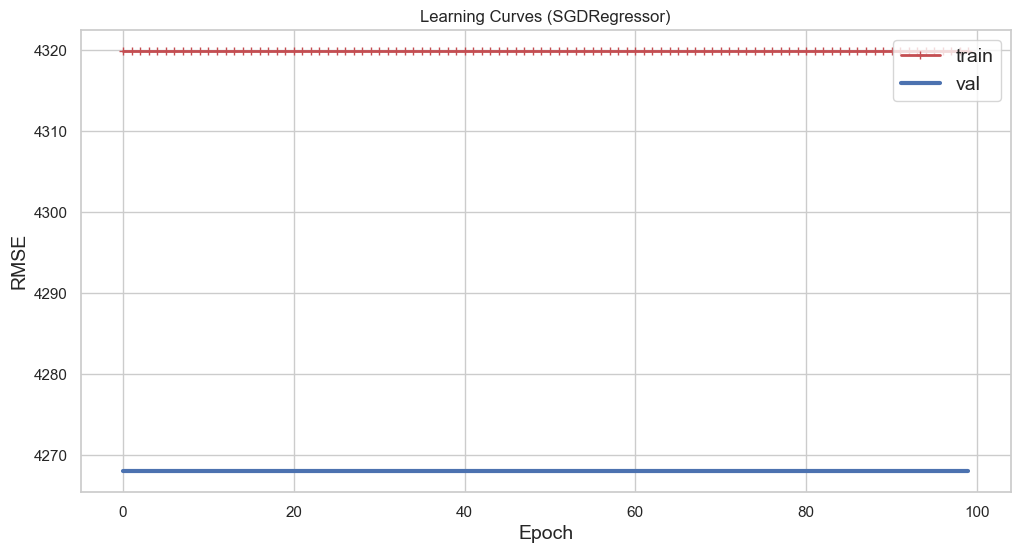

In [59]:
plt.figure(figsize=(12, 6))
plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")
plt.legend(loc="upper right", fontsize=14)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("RMSE", fontsize=14)
plt.title("Learning Curves (SGDRegressor)")
plt.grid(True)
plt.show()

6.5 Train Other Models

In [60]:
models = {
    'Linear Regression': LinearRegression(),
    'SGD Regressor': sgd,
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

In [61]:
print("Training Decision Tree...")
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

Training Decision Tree...


In [62]:
print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

Training Random Forest...


6.6 Evaluate all models

In [63]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

In [64]:
print("\n=== Model Performance ===")
for name, model in models.items():
    if name != 'SGD Regressor':
        model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"\n{name}:")
    print(f"  MAE: {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²: {r2:.4f}")


=== Model Performance ===

Linear Regression:
  MAE: 3345.14
  RMSE: 4214.07
  R²: 0.6483

SGD Regressor:
  MAE: 3397.54
  RMSE: 4268.05
  R²: 0.6392

Decision Tree:
  MAE: 900.90
  RMSE: 1458.84
  R²: 0.9579

Random Forest:
  MAE: 710.26
  RMSE: 1060.88
  R²: 0.9777


In [31]:
model_performance['Linear Regression'] = evaluate_model(y_test, y_pred_rf, 'Linear Regression')
model_performance['Decision Tree'] = evaluate_model(y_test, y_pred_dt, 'Decision Tree')
model_performance['Random Forest'] = evaluate_model(y_test, y_pred_rf, 'Random Forest')

In [32]:
results_df = pd.DataFrame(model_performance).T
print("\n=== Model Performance ===")
display(results_df)


=== Model Performance ===


,MAE,RMSE,R2
Linear Regression,710.257202,1060.876601,0.977711
Decision Tree,900.897291,1458.836303,0.957853
Random Forest,710.257202,1060.876601,0.977711


In [33]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lin = lin_reg.predict(X_test_scaled)

6.7 Before/After Scatter Plot

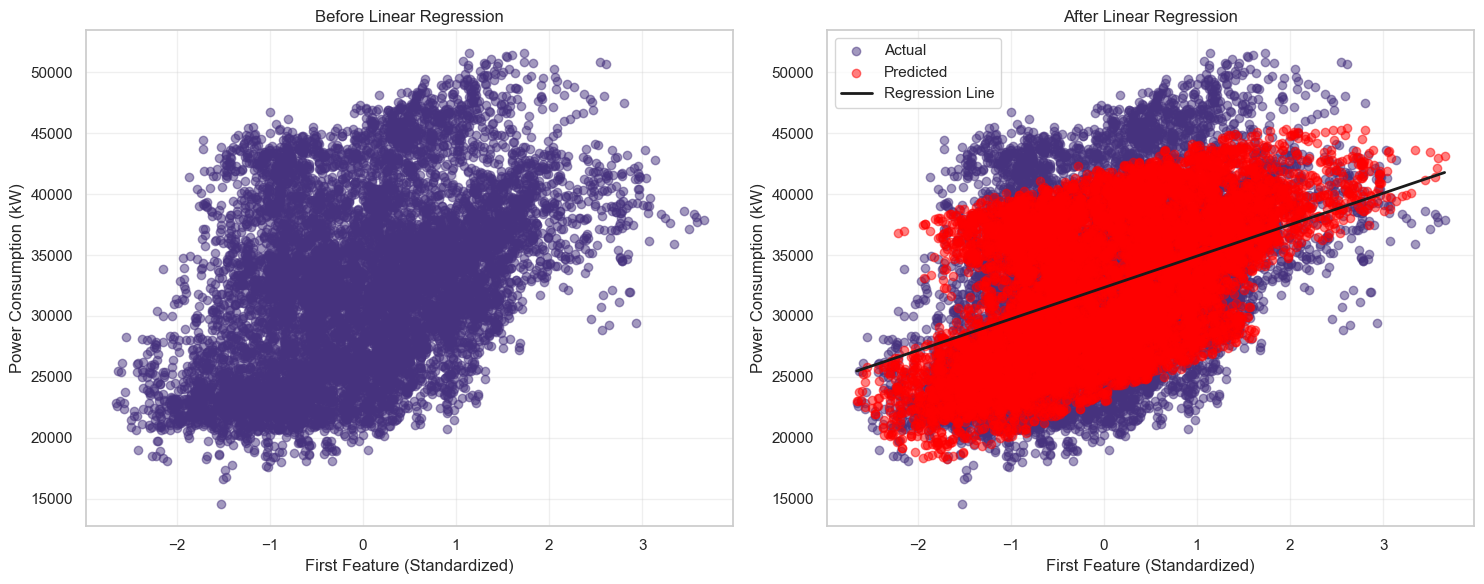

In [34]:
# A figure with two subplots
plt.figure(figsize=(15, 6))

# First subplot (before regression)
plt.subplot(1, 2, 1)
plt.scatter(X_test_scaled[:, 0], y_test, alpha=0.5)
plt.title("Before Linear Regression")
plt.xlabel("First Feature (Standardized)")
plt.ylabel("Power Consumption (kW)")
plt.grid(True, alpha=0.3)

# Second subplot (after regression)
plt.subplot(1, 2, 2)
plt.scatter(X_test_scaled[:, 0], y_test, alpha=0.5, label="Actual")

# Predictions from linear regression
lin_reg = models['Linear Regression']
y_pred_lin = lin_reg.predict(X_test_scaled)
plt.scatter(X_test_scaled[:, 0], y_pred_lin, alpha=0.5, color='red', label="Predicted")

# Plot regression line
x_range = np.linspace(X_test_scaled[:, 0].min(), X_test_scaled[:, 0].max(), 100).reshape(-1, 1)
X_range = np.zeros((100, X_test_scaled.shape[1]))
X_range[:, 0] = x_range.ravel()
y_range = lin_reg.predict(X_range)
plt.plot(x_range, y_range, 'k-', linewidth=2, label="Regression Line")

plt.title("After Linear Regression")
plt.xlabel("First Feature (Standardized)")
plt.ylabel("Power Consumption (kW)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

7. Save the Best Model

In [35]:
best_model = models['Random Forest']
joblib.dump(best_model, 'power_consumption_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\nBest model (Random Forest) and scaler saved successfully!")


Best model (Random Forest) and scaler saved successfully!


7.1 Save Model To FASTAPI Directory

In [36]:
api_models_dir = '../power-consumption-api/app/models/'
os.makedirs(api_models_dir, exist_ok=True)

joblib.dump(best_model, os.path.join(api_models_dir, 'power_consumption_model.joblib'))
joblib.dump(scaler, os.path.join(api_models_dir, 'power_consumption_scaler.joblib'))

print(f"Model and scaler saved to API directory: {api_models_dir}")

Model and scaler saved to API directory: ../power-consumption-api/app/models/


8. Prediction Function

In [37]:
def predict_power_consumption(input_data):
    """Function to make predictions using the trained model."""
    model = joblib.load('power_consumption_model.pkl')
    scaler = joblib.load('scaler.pkl')

    input_df = pd.DataFrame([input_data])
    input_df = input_df[features]

    input_scaled = scaler.transform(input_df)
    prediction = model.predict(input_scaled)
    return prediction[0]

In [38]:
input_data = {
    'Temperature': 25.5,
    'Humidity': 60.0,
    'WindSpeed': 10.0,
    'GeneralDiffuseFlows': 0.5,
    'DiffuseFlows': 0.3,
    'Hour': 14,
    'DayOfWeek': 2,
    'Month': 6
}

In [41]:
input_df = pd.DataFrame([input_data])
input_df = input_df[features]
input_scaled = scaler.transform(input_df)
prediction = model.predict(input_scaled)
print(f"Predicted power consumption: {prediction[0]:.2f} kW")

Predicted power consumption: 33957.43 kW


Feature Importance for tree-based models

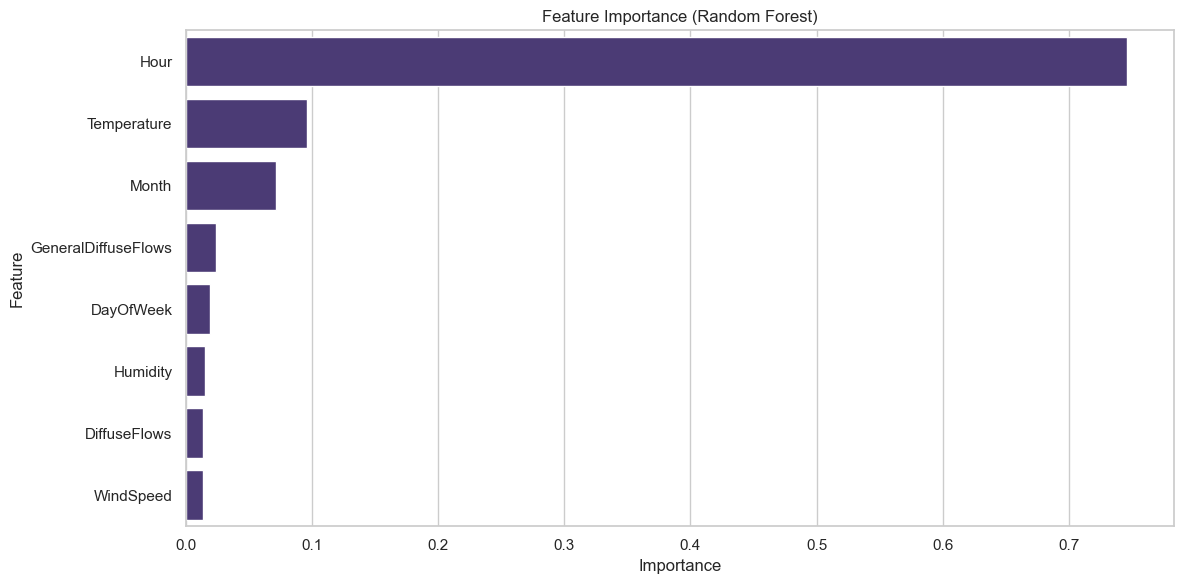


=== Analysis Complete ===


In [42]:
if hasattr(best_model, 'feature_importances_'):
    plt.figure(figsize=(12, 6))
    feature_importance = pd.DataFrame({
        'Feature': features,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title('Feature Importance (Random Forest)')
    plt.tight_layout()
    plt.show()

print("\n=== Analysis Complete ===")